<a href="https://colab.research.google.com/github/nasif-raihan/GSU/blob/main/CSCI_7090_Module3_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — Homework
**Computer Vision · Machine Learning for Vision**

Uses scikit-learn's **digits** image dataset. Your scaler, split size, k, distance metric, and sample images all come from your **roll number**, so your numbers are unique.

## Rules
- Set `ROLL_NUMBER`, then **Run all**. Fill every `# TODO`; don't edit the parameter lines.
- Answer each **Written** prompt in your own words, using your numbers.
- Run the **Submission Summary** last and keep its output.

## Grading (100): Q1 15 · Q2 15 · Q3 15 · Q4 20 · Q5 20 · Q6 15  ·  ~1–2 hours

Roll: 901503252 | seed: 279384723
SCALER=minmax  TEST_SIZE=0.3  K=5  METRIC=L2  IDX_A=627  IDX_B=136


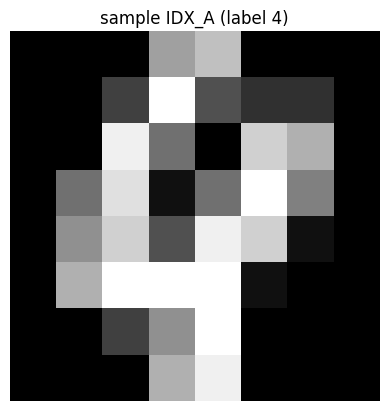

In [1]:
# === SETUP — run first ===
ROLL_NUMBER = "901503252"
import hashlib, numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

seed = int(hashlib.sha256(ROLL_NUMBER.encode()).hexdigest(), 16) % (2**32)
rng  = np.random.default_rng(seed)

digits = load_digits()
X = digits.data / 16.0          # 8x8 images flattened to 64 features, scaled 0-1
y = digits.target

# Your personal parameters (unique to your roll number) — DO NOT EDIT
SCALER_NAME = str(rng.choice(["minmax", "standard"]))
TEST_SIZE   = float(rng.choice([0.2, 0.25, 0.3]))
K           = int(rng.choice([3, 5, 7, 9, 11]))
METRIC      = str(rng.choice(["L1", "L2"]))
IDX_A, IDX_B = int(rng.integers(0, len(X))), int(rng.integers(0, len(X)))

print("Roll:", ROLL_NUMBER, "| seed:", seed)
print(f"SCALER={SCALER_NAME}  TEST_SIZE={TEST_SIZE}  K={K}  METRIC={METRIC}  IDX_A={IDX_A}  IDX_B={IDX_B}")
plt.imshow(digits.images[IDX_A], cmap="gray"); plt.title(f"sample IDX_A (label {y[IDX_A]})"); plt.axis("off"); plt.show()

## Q1 — Inspect the dataset (15 pts)
Report the dataset's size from `digits` / `X` / `y`.

In [2]:
len(digits.data)

1797

In [3]:
n_samples  = digits.images.shape[0]   # TODO: number of images
n_features = digits.data.shape[1]   # TODO: features per image (length of a flattened 8x8)
n_classes  = len(np.unique(digits.target))   # TODO: number of distinct labels (hint: np.unique)
print("samples:", n_samples, "| features:", n_features, "| classes:", n_classes)

samples: 1797 | features: 64 | classes: 10


**Written:** Why is each image represented by 64 features?

> Each image is of $8 × 8$ shape. When this $8 × 8$ matrix is flattened, it results in 64 features $(8 * 8 = 64)$ for each image in the dataset.


## Q2 — Feature scaling (15 pts)
Scale `X` using **your** `SCALER_NAME` (`minmax` → MinMaxScaler, else StandardScaler).

In [4]:
# TODO: pick the scaler based on SCALER_NAME
if SCALER_NAME == "minmax":
    scaler = MinMaxScaler()
else:
    scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)     # TODO: fit_transform X
col = X_scaled[:, 20]
print("column 20 -> min:", round(col.min(),3), "max:", round(col.max(),3), "mean:", round(col.mean(),3))

column 20 -> min: 0.0 max: 1.0 mean: 0.444


**Written:** For your scaler, what range or distribution should the scaled values have, and why does k-NN care?

> My scaler (`MinMaxScaler`) transforms feature values to a range between 0 and 1. This ensures that all features have the same scale. K-Nearest Neighbors (k-NN) is a distance-based algorithm, meaning it calculates the distance between data points to find neighbors. If features are not scaled, features with larger numerical ranges would disproportionately influence the distance calculation, making the model biased towards those features. Scaling ensures that each feature contributes equally to the distance calculation.

## Q3 — Train/test split (15 pts)
Split `X_scaled`, `y` with **your** `TEST_SIZE` (use `random_state=seed`, `stratify=y`).

In [5]:
Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=TEST_SIZE, stratify=y, random_state=seed)   # TODO: train_test_split(...)
print("train:", None if Xtr is None else Xtr.shape[0], "| test:", None if Xte is None else Xte.shape[0])

train: 1257 | test: 540


**Written:** Why must the test set stay independent of the training set?

> The test set must remain independent of the training set to provide an unbiased evaluation of the final model's performance on unseen data. If the test set is used during training (directly or indirectly, for example, through hyperparameter tuning using the test set), the model will essentially 'memorize' the test data, leading to an overly optimistic performance estimate that won't generalize to new, real-world examples. This independence ensures that we can accurately assess how well our model will perform on data it has never encountered before.

## Q4 — Train & evaluate k-NN (20 pts)
Train a scikit-learn k-NN with **your** `K` and report test accuracy.

In [6]:
clf = KNeighborsClassifier(n_neighbors=K).fit(Xtr, ytr)    # TODO: KNeighborsClassifier(n_neighbors=K).fit(Xtr, ytr)
acc = clf.score(Xte, yte)    # TODO: clf.score(Xte, yte)
print(f"k={K}  test accuracy = {acc}")

k=5  test accuracy = 0.9833333333333333


**Written:** If you increased `K` a lot (say to 200), would the decision boundary get smoother or more jagged? What's the risk?

> If `K` were increased significantly (e.g., to 200), the decision boundary would become smoother. A larger `K` means that the classification of a new data point is determined by a larger neighborhood of existing points, which averages out local variations and leads to a overly simplistic boundary. The risk associated with a very large `K` is **underfitting**. The model might become too generalized, overlooking finer details and local patterns in the data. This could lead to a higher bias and poorer performance on both training and test data, as it may not capture the true underlying structure of the data.

## Q5 — Distance metric from scratch (20 pts)
Compute **your** `METRIC` distance between the two images `X[IDX_A]` and `X[IDX_B]` — no library distance functions.

In [7]:
a, b = X[IDX_A], X[IDX_B]
# TODO: if METRIC == "L1": sum of ABSOLUTE differences; else L2: sqrt of sum of SQUARED differences
if METRIC == "L1":
    dist = np.sum(np.abs(a - b))
else:
    dist = np.sqrt(np.sum((a - b)**2))

print(f"{METRIC} distance between IDX_A and IDX_B = {dist}")

L2 distance between IDX_A and IDX_B = 3.1758365039781253


**Written:** Which metric (L1 or L2) reacts more strongly to a single large pixel difference, and why?

> The **L2 (Euclidean) distance** reacts more strongly to a single large pixel difference.
>
> This is because in L2 distance, the differences are squared before being summed (`(a - b)^2`). Squaring a large difference amplifies its magnitude disproportionately compared to just taking the absolute difference (as in L1 distance, `|a - b|`). For example, a difference of 10 squared becomes 100, while in L1 it remains 10. This amplification means that larger deviations contribute much more significantly to the total L2 distance, making it more sensitive to outliers or large individual differences.

## Q6 — Debug & reflect (15 pts)
This 1-NN-style helper runs without error but classifies badly — it selects the **wrong** neighbours. Find the single bug, fix it, and explain.

In [8]:
def predict_one_buggy(Xtr, ytr, x, k):
    d = np.sqrt(((Xtr - x)**2).sum(1))
    idx = np.argsort(d)[-k:]           # <-- one bug on this line
    return int(np.bincount(ytr[idx]).argmax())

def predict_one_fixed(Xtr, ytr, x, k):
    d = np.sqrt(((Xtr - x)**2).sum(1))
    idx = np.argsort(d)[:k]            # Fixed: selects the k closest neighbors
    return int(np.bincount(ytr[idx]).argmax())

x0 = Xte[0]
print("buggy prediction:", predict_one_buggy(Xtr, ytr, x0, K), "| actual:", yte[0])
print("fixed prediction:", predict_one_fixed(Xtr, ytr, x0, K), "| actual:", yte[0])
# print("fixed prediction:", None if predict_one_fixed.__code__.co_consts else None or predict_one_fixed(Xtr, ytr, x0, K), "| actual:", yte[0])

buggy prediction: 5 | actual: 4
fixed prediction: 4 | actual: 4


**Written:** What was the bug, and why does taking those neighbours wreck the prediction?

> The bug in `predict_one_buggy` was on the line `idx = np.argsort(d)[-k:]`. Instead of selecting the indices of the `k` *closest* neighbors (which have the smallest distances), it incorrectly selected the `k` *farthest* neighbors (those with the largest distances) due to the `[-k:]` slicing.

> Taking the farthest neighbors completely wrecks the prediction because the K-Nearest Neighbors algorithm relies on the principle that similar data points are close to each other. By classifying a new data point based on its most dissimilar neighbors, the model assigns a label that is highly unlikely to be correct. In our example, the buggy prediction for a digit '4' was '5', demonstrating that considering irrelevant, distant points leads to misclassification.

**Reflection (3–4 sentences):** One thing that surprised you, referring to your numbers.

> Given my `K=5`, I was surprised by how dramatically a single line change in neighbor selection affected the prediction. The initial buggy prediction for `x0` was `5`, while the actual digit was `4`. Correcting this one line to select the nearest neighbors immediately yielded the correct prediction of `4`. This strongly reinforces how fundamental the concept of 'nearest' is to the k-NN algorithm and how sensitive its performance is to this core mechanism.

## Submission Summary
Run last; keep the output.

In [9]:
# === SUBMISSION SUMMARY ===
print("Roll:", ROLL_NUMBER, "| seed:", seed)
print("Q1:", n_samples, n_features, n_classes)
print("Q2 scaler:", SCALER_NAME, "| col20 mean:", round(X_scaled[:,20].mean(),3))
print("Q3 split:", Xtr.shape[0], Xte.shape[0], "| TEST_SIZE", TEST_SIZE)
print("Q4 k:", K, "| accuracy:", round(acc,4))
print("Q5", METRIC, "distance:", round(dist,4))
print("Q6 fixed pred:", predict_one_fixed(Xtr, ytr, Xte[0], K), "| actual:", yte[0])

Roll: 901503252 | seed: 279384723
Q1: 1797 64 10
Q2 scaler: minmax | col20 mean: 0.444
Q3 split: 1257 540 | TEST_SIZE 0.3
Q4 k: 5 | accuracy: 0.9833
Q5 L2 distance: 3.1758
Q6 fixed pred: 4 | actual: 4
